In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlopen
import json
import os
from json import loads
import plotly.express as px


Helper functions to search for school

In [26]:
school_df = pd.read_csv("schoolname_UNITID.csv")

def search_school(school_name):
    # Case-insensitive search for school name
    result = school_df[school_df["inst_name"].str.contains(school_name, case=False, na=False)]
    if result.empty:
        print(f"No matches found for '{school_name}'.")
    return result

def get_school_name(unitid):
    # Fetch school directory data
    url = f"https://educationdata.urban.org/api/v1/college-university/ipeds/directory/2020/?unitid={unitid}"
    response = urlopen(url)
    data = loads(response.read())
    
    results = data.get("results", [])
    if results:
        school_name = results[0].get("inst_name", "Unknown")
        return school_name
    else:
        return f"No school found for unitid {unitid}"

def search_school_by_state(state_abbr):
    """Search for schools in a given state (by abbreviation) and return a DataFrame with unitid and school name.
    """
    url = "https://educationdata.urban.org/api/v1/college-university/ipeds/directory/2020/"
    
    try:
        response = urlopen(url)
        data = loads(response.read())
        results = data.get("results", [])
        
        if not results:
            print(f"No schools found.")
            return pd.DataFrame()
        
        # Filter results manually based on state_abbr
        filtered_results = [
            {"unitid": result.get("unitid"), "school_name": result.get("inst_name", "Unknown")}
            for result in results if result.get("state_abbr") == state_abbr.upper()
        ]
        
        if not filtered_results:
            print(f"No schools found in {state_abbr}.")
            return pd.DataFrame()
        
        return pd.DataFrame(filtered_results)
    
    except Exception as e:
        print(f"Error fetching data: {e}")
        return pd.DataFrame()

In [ ]:
# Debug: Let's examine the data structure to understand why we're getting stacked bars
enrollment_df = pd.read_csv("../data/dbt-processed/enrollment.csv")

print("DataFrame shape:", enrollment_df.shape)
print("\nDataFrame columns:")
print(enrollment_df.columns.tolist())

# Check the specific school and year data
print(f"\nFiltering for 'New Jersey Institute of Technology' and year 2023:")
filtered_data = enrollment_df[
    (enrollment_df["SURVEY_YEAR"] == 2023) & 
    (enrollment_df["INSTITUTION_NAME"] == "New Jersey Institute of Technology")
]
print(f"Filtered data shape: {filtered_data.shape}")

if not filtered_data.empty:
    print("\nFiltered data:")
    print(filtered_data)
    
    print(f"\nGRAND_TOTAL_MEN values: {filtered_data['GRAND_TOTAL_MEN'].values}")
    print(f"GRAND_TOTAL_WOMEN values: {filtered_data['GRAND_TOTAL_WOMEN'].values}")
    
    # Check if there are multiple rows (which would cause stacking)
    print(f"\nNumber of rows for this school/year: {len(filtered_data)}")
    
    # Show all columns that might be related to enrollment
    enrollment_cols = [col for col in filtered_data.columns if any(keyword in col.lower() for keyword in ['men', 'women', 'total', 'enroll'])]
    print(f"\nEnrollment-related columns: {enrollment_cols}")
    
    if len(enrollment_cols) > 0:
        print("\nValues in enrollment-related columns:")
        print(filtered_data[enrollment_cols])
else:
    print("No data found for this school and year!")
    print("\nAvailable schools in 2023:")
    schools_2023 = enrollment_df[enrollment_df["SURVEY_YEAR"] == 2023]["INSTITUTION_NAME"].unique()
    print(schools_2023[:10])  # Show first 10 schools


In [ ]:
# Fixed version of the gender enrollment chart function
def create_gender_enrollment_bar_chart_fixed(df, selected_school, selected_year):
    # Filter data
    filtered_df = df[
        (df["SURVEY_YEAR"] == selected_year) & 
        (df["INSTITUTION_NAME"] == selected_school)
    ].copy()
    
    if filtered_df.empty:
        print(f"No data found for {selected_school} in {selected_year}")
        return None
    
    # If there are multiple rows, we need to aggregate them
    if len(filtered_df) > 1:
        print(f"Found {len(filtered_df)} rows for {selected_school} in {selected_year}. Aggregating...")
        # Sum the values across all rows
        men_total = filtered_df["GRAND_TOTAL_MEN"].sum()
        women_total = filtered_df["GRAND_TOTAL_WOMEN"].sum()
    else:
        men_total = filtered_df["GRAND_TOTAL_MEN"].iloc[0]
        women_total = filtered_df["GRAND_TOTAL_WOMEN"].iloc[0]
    
    # Create simple data for plotting
    plot_data = {
        "Gender": ["Men", "Women"],
        "Count": [men_total, women_total]
    }
    plot_df = pd.DataFrame(plot_data)
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Create bar chart
    bars = ax.bar(
        plot_df["Gender"],
        plot_df["Count"],
        color=['steelblue', 'lightcoral']
    )
    
    # Customize chart
    ax.set_title(f"Gender Enrollment at {selected_school} ({selected_year})")
    ax.set_ylabel("Number of Students")
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom'
        )
    
    # Adjust layout
    plt.tight_layout()
    
    return fig

# Test the fixed version
fig = create_gender_enrollment_bar_chart_fixed(
    enrollment_df,
    "New Jersey Institute of Technology", 
    2023
)
if fig:
    plt.show()


In [27]:
search_school_by_state("nj")

,unitid,school_name
0,183488,Eastwick College-Hackensack
1,183600,Assumption College for Sisters
2,183655,Atlantic Cape Community College
3,183725,Fortis Institute-Wayne
4,183743,Bergen Community College
...,...,...
160,493628,Pro Beauty Academy
161,493707,Yeshiva Gedolah of Woodlake Village
162,493716,Yeshiva Gedola Tiferes Yaakov Yitzchok
163,495314,Hackensack Meridian School of Medicine


Get a UNITIDs of New Jersey schools

In [28]:
NJ_schools = search_school_by_state("nj")

if not NJ_schools.empty:
    # Extract the list of unitid values
    NJ_unitid_list = NJ_schools["unitid"].tolist()
    print("List of UNITIDs for schools in New Jersey:", NJ_unitid_list)

    # Fetch and print school names for each unitid
    for unitid in NJ_unitid_list:
        school_name = get_school_name(unitid)
        print(f"UNITID: {unitid}, School Name: {school_name}")
else:
    print("No schools found in New Jersey.")

List of UNITIDs for schools in New Jersey: [183488, 183600, 183655, 183725, 183743, 183789, 183804, 183822, 183859, 183877, 183910, 183938, 183974, 183983, 184047, 184056, 184092, 184180, 184205, 184278, 184348, 184427, 184481, 184506, 184603, 184612, 184694, 184746, 184773, 184782, 184791, 184816, 184870, 184959, 184968, 184995, 185129, 185174, 185262, 185332, 185396, 185466, 185509, 185536, 185572, 185590, 185679, 185721, 185758, 185767, 185828, 185873, 185970, 186016, 186034, 186052, 186122, 186131, 186186, 186201, 186283, 186371, 186380, 186399, 186405, 186423, 186432, 186469, 186584, 186593, 186618, 186645, 186867, 186876, 186900, 187000, 187046, 187134, 187198, 187444, 194718, 245625, 247603, 249140, 363077, 365763, 368230, 374574, 374592, 383279, 384421, 407391, 407407, 407425, 414063, 417831, 420130, 420343, 421878, 430218, 430403, 431716, 436003, 437723, 440794, 441548, 442073, 443216, 443225, 445300, 446224, 446303, 448354, 448983, 449658, 451370, 451398, 453215, 455187, 4551

In [ ]:
NY_schools = search_school_by_state("NY")

if not NY_schools.empty:
    # Extract the list of unitid values
    NY_unitid_list = NY_schools["unitid"].tolist()
    print("List of UNITIDs for schools in New Jersey:", NY_unitid_list)

    # Fetch and print school names for each unitid
    for unitid in NY_unitid_list:
        school_name = get_school_name(unitid)
        print(f"UNITID: {unitid}, School Name: {school_name}")
else:
    print("No schools found in New Jersey.")

Process complete data files for enrollment data

In [ ]:
def process_enrollment_data(unitid, folder_path="effy"):
    """
    Process enrollment data for a given unitid and return the results as a DataFrame.
    """
    column_mapping_new = {
        "EFFYDLEV": "Level_of_student",
        "EFYDETOT": "All_students_enrolled"
    }

    column_mapping_old = {
        "EFDELEV": "Level_of_student",
        "EFDETOT": "All_students_enrolled"
    }

    final_column_mapping = {
        "Level_of_student": "level_of_study",
        "All_students_enrolled": "headcount"
    }

    level_mapping = {
        1: "Undergraduate",
        2: "Graduate",
        99: "Total"
    }

    dataframes = []

    for filename in os.listdir(folder_path):
        if filename.endswith("_dist.csv"):
            if filename.startswith("effy"):
                year = int(filename[4:8])
                column_mapping = column_mapping_new
            elif filename.startswith("ef") and filename.endswith("a_dist.csv"):
                year = int(filename[2:6])
                column_mapping = column_mapping_old
            else:
                continue

            # print(f"Processing {filename} for unitid {unitid}")

            iped_csv = pd.read_csv(os.path.join(folder_path, filename))
            iped_csv = iped_csv[iped_csv["UNITID"] == unitid]
            iped_csv = iped_csv.rename(columns=column_mapping)
            iped_csv = iped_csv[list(column_mapping.values())]
            iped_csv = iped_csv.rename(columns=final_column_mapping)
            iped_csv = iped_csv[iped_csv["level_of_study"].isin(level_mapping.keys())]
            iped_csv["level_of_study"] = iped_csv["level_of_study"].replace(level_mapping)
            iped_csv["year"] = year
            dataframes.append(iped_csv)

    if not dataframes:
        print(f"No enrollment data found for unitid {unitid}.")
        return pd.DataFrame()  # Return an empty DataFrame if no data is found

    final_df = pd.concat(dataframes, ignore_index=True)

    # Add university_name and unitid columns
    final_df["university_name"] = get_school_name(unitid)
    final_df["unitid"] = unitid

    # Reorder columns to move unitid and university_name to the front
    column_order = ["unitid", "university_name"] + [col for col in final_df.columns if col not in ["unitid", "university_name"]]
    final_df = final_df[column_order]

    return final_df

In [30]:
# for unitid in NJ_unitid_list:
#     process_enrollment_data(unitid)

all_data = pd.DataFrame()
for unitid in NJ_unitid_list:
    unitid_data = process_enrollment_data(unitid)
    if not unitid_data.empty:
        all_data = pd.concat([all_data, unitid_data], ignore_index=True)

output_path = "effy/NJ_enrollment_data.csv"
all_data.to_csv(output_path, index=False)

print(f"All enrollment data saved to: {output_path}")

All enrollment data saved to: effy/NJ_enrollment_data.csv


Example chart

In [20]:
# Read enrollment data and filter for NJIT in 2023
enrollment_df = pd.read_csv("../data/dbt-processed/enrollment.csv", low_memory=False)

# Looking at the output, there appear to be duplicate rows for NJIT
# Let's check what's causing this and deduplicate
njit_df = enrollment_df[
    (enrollment_df["INSTITUTION_NAME"] == "New Jersey Institute of Technology") &
    (enrollment_df["SURVEY_YEAR"].isin([2022, 2023])) &
    (enrollment_df["UNDERGRADUATE_GRADUATE_LEVEL"] == "Undergraduate")
].drop_duplicates()

print("NJIT 2023 enrollment data shape:", njit_df.shape)
njit_df.head()


NJIT 2023 enrollment data shape: (2, 20)


,INSTITUTION_ID,SURVEY_YEAR,INSTITUTION_NAME,CITY,STATE_ABBR,STUDENT_LEVEL_AND_DEGREE_STATUS,UNDERGRADUATE_GRADUATE_LEVEL,ORIGINAL_LEVEL_OF_STUDY,GRAND_TOTAL,GRAND_TOTAL_MEN,GRAND_TOTAL_WOMEN,AMERICAN_INDIAN_TOTAL,ASIAN_TOTAL,BLACK_AFRICAN_AMERICAN_TOTAL,HISPANIC_LATINO_TOTAL,NATIVE_HAWAIIAN_PACIFIC_ISLANDER_TOTAL,WHITE_TOTAL,TWO_OR_MORE_RACES_TOTAL,RACE_ETHNICITY_UNKNOWN_TOTAL,US_NONRESIDENT_TOTAL
280697,185828,2022,New Jersey Institute of Technology,Newark,NJ,"All students, Undergraduate total",Undergraduate,Undergraduate,10299.0,7423.0,2876.0,11.0,2165.0,924.0,2199.0,3.0,3039.0,324.0,1196.0,438.0
280705,185828,2023,New Jersey Institute of Technology,Newark,NJ,"All students, Undergraduate total",Undergraduate,Undergraduate,9945.0,7134.0,2811.0,10.0,2041.0,946.0,2494.0,3.0,2923.0,312.0,627.0,589.0


/var/folders/63/lvrmvc5j7pn6bxjxzcd1txt00000gn/T/ipykernel_13576/3620170202.py:46: DtypeWarning:

Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.



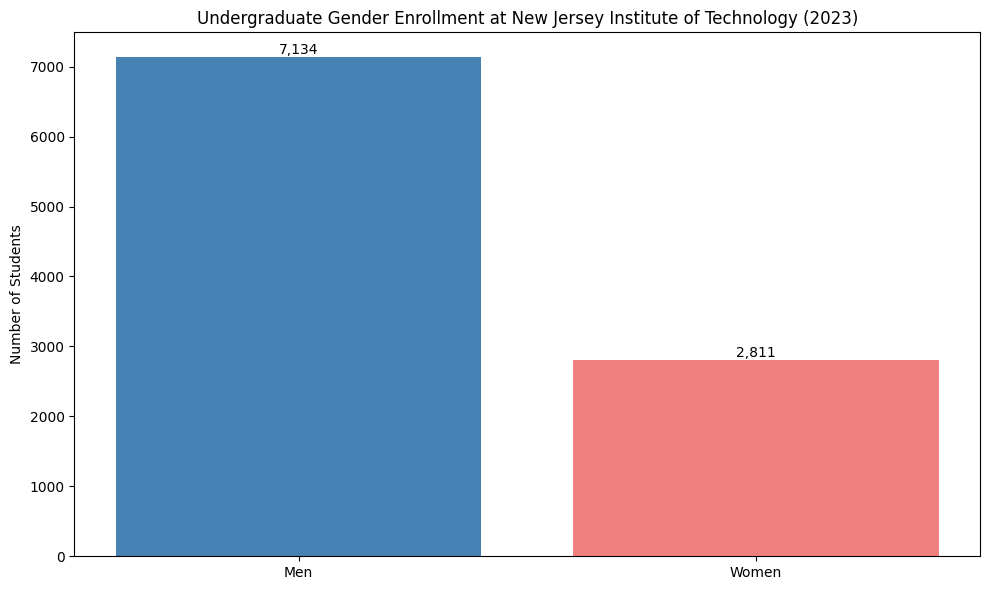

In [14]:
# Plot gender enrollment bar chart for a single school and year
import pandas as pd
import matplotlib.pyplot as plt

def create_gender_enrollment_bar_chart(df, selected_school="New Jersey Institute of Technology", selected_year=2023):
    # Filter data
    filtered_df = df[
        (df["SURVEY_YEAR"] == selected_year) & 
        (df["INSTITUTION_NAME"] == selected_school) &
        (df["UNDERGRADUATE_GRADUATE_LEVEL"] == "Undergraduate")
    ].copy()
    
    # Get single values for men and women
    men_count = filtered_df["GRAND_TOTAL_MEN"].iloc[0]
    women_count = filtered_df["GRAND_TOTAL_WOMEN"].iloc[0]
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create bar chart
    x = ["Men", "Women"]
    y = [men_count, women_count]
    bars = ax.bar(x, y, color=['steelblue', 'lightcoral'])
    
    # Customize chart
    ax.set_title(f"Undergraduate Gender Enrollment at {selected_school} ({selected_year})")
    ax.set_ylabel("Number of Students")
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom'
        )
    
    # Adjust layout
    plt.tight_layout()
    
    return fig

# Example usage:
enrollment_df = pd.read_csv("../data/dbt-processed/enrollment.csv")
fig = create_gender_enrollment_bar_chart(enrollment_df)
plt.show()


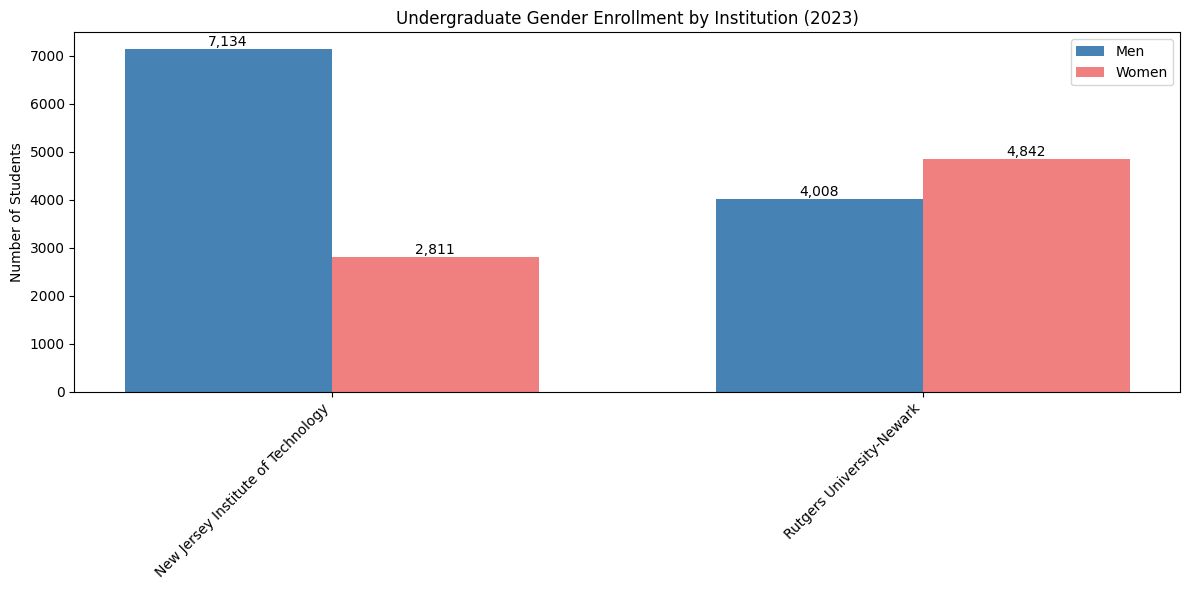

In [ ]:
def create_gender_enrollment_multi_school_bar_chart(df, selected_schools):
    """
    Create a bar chart comparing gender enrollment across multiple schools for the most recent year.
    
    Args:
        df: DataFrame containing enrollment data
        selected_schools: List of school names to include in comparison
    """
    # Get most recent year
    max_year = df["SURVEY_YEAR"].max()
    
    # Filter data for selected schools and year
    filtered_df = df[
        (df["INSTITUTION_NAME"].isin(selected_schools)) &
        (df["SURVEY_YEAR"].isin([2022, 2023])) &
        (df["UNDERGRADUATE_GRADUATE_LEVEL"] == "Undergraduate")
    ].copy()
    
    # Remove duplicates by keeping only the latest year for each institution
    filtered_df = filtered_df.sort_values('SURVEY_YEAR', ascending=False).drop_duplicates('INSTITUTION_NAME')
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Set width of bars and positions of the bars
    bar_width = 0.35
    x = range(len(selected_schools))
    
    # Create bars
    men_bars = ax.bar([i - bar_width/2 for i in range(len(filtered_df))], 
                     filtered_df["GRAND_TOTAL_MEN"].values,
                     bar_width, 
                     label='Men',
                     color='steelblue')
    
    women_bars = ax.bar([i + bar_width/2 for i in range(len(filtered_df))],
                       filtered_df["GRAND_TOTAL_WOMEN"].values,
                       bar_width,
                       label='Women', 
                       color='lightcoral')
    
    # Customize chart
    ax.set_title(f"Undergraduate Gender Enrollment by Institution ({max_year})")
    ax.set_ylabel("Number of Students")
    ax.set_xticks(x)
    ax.set_xticklabels(selected_schools, rotation=45, ha='right')
    
    # Add legend
    ax.legend()
    
    # Add value labels on bars
    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2.,
                   height,
                   f'{int(height):,}',
                   ha='center',
                   va='bottom',
                   rotation=0)
    
    add_labels(men_bars)
    add_labels(women_bars)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig

selected_schools = ["New Jersey Institute of Technology", "Rutgers University-Newark"]
fig = create_gender_enrollment_multi_school_bar_chart(enrollment_df, selected_schools)
plt.show()


<Figure size 10000x10000 with 0 Axes>

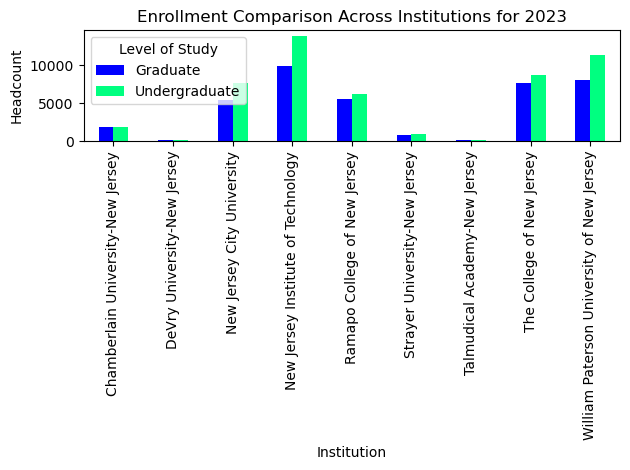

In [3]:
data = pd.read_csv("effyYEAR/NJ_enrollment_data.csv")

year = 2023

filtered_data = data[data["year"] == year]

pivot_data = filtered_data.pivot_table(index="university_name", columns="level_of_study", values="headcount", aggfunc="sum")

plt.figure(figsize=(100, 100))
pivot_data.plot(kind="bar", stacked=False, colormap="winter")
plt.title(f"Enrollment Comparison Across Institutions for {year}")
plt.xlabel("Institution"); plt.ylabel("Headcount")
plt.xticks(rotation=90); plt.legend(title="Level of Study"); plt.tight_layout()
plt.show()

In [14]:
unitid_list = [
    185828, 196079, 126775, 190576, 155399, 203517, 176080, 180461, 200332, 
    207388, 232982, 196060, 180489, 228796, 100663, 100706, 110714, 126562, 
    130943, 141574, 204857
]
for id in unitid_list:
    print(id, "-", get_school_name(id))

# Process enrollment data for this group of institutions
all_data = pd.DataFrame()
for unitid in unitid_list:
    unitid_data = process_enrollment_data(unitid)
    if not unitid_data.empty:
        all_data = pd.concat([all_data, unitid_data], ignore_index=True)

output_path = "effyYEAR/SELECTED_enrollment_data.csv"
all_data.to_csv(output_path, index=False)

print(f"All enrollment data saved to: {output_path}")

185828 - New Jersey Institute of Technology
196079 - Binghamton University
126775 - Colorado School of Mines
190576 - CUNY Graduate School and University Center
155399 - Kansas State University
203517 - Kent State University at Kent
176080 - Mississippi State University
180461 - Montana State University
200332 - North Dakota State University-Main Campus
207388 - Oklahoma State University-Main Campus
232982 - Old Dominion University
196060 - SUNY at Albany
180489 - The University of Montana
228796 - The University of Texas at El Paso
100663 - University of Alabama at Birmingham
100706 - University of Alabama in Huntsville
110714 - University of California-Santa Cruz
126562 - University of Colorado Denver/Anschutz Medical Campus
130943 - University of Delaware
141574 - University of Hawaii at Manoa
204857 - Ohio University-Main Campus
All enrollment data saved to: effyYEAR/SELECTED_enrollment_data.csv


In [3]:

data = pd.read_csv("effyYEAR/SELECTED_enrollment_data.csv")

years = data["year"].unique()

# Create the initial bar chart
initial_year = years[0]
filtered_data = data[data["year"] == initial_year]
pivot_data = filtered_data.pivot_table(index="university_name", columns="level_of_study", values="headcount", aggfunc="sum")
pivot_data = pivot_data.reset_index()
pivot_data["university_name"] = pivot_data["university_name"].apply(lambda x: x[:15] + "..." if len(x) > 15 else x)
melted_data = pd.melt(pivot_data, id_vars=["university_name"], var_name="Level of Study", value_name="Headcount")

fig = px.bar(melted_data, x="university_name", y="Headcount", color="Level of Study", 
             title=f"Enrollment Comparison Across Institutions for {initial_year}",
             labels={"university_name": "Institution", "Headcount": "Headcount"},
             text_auto=True)


fig.update_layout(
    xaxis_title="Institution",
    yaxis_title="Headcount",
    xaxis_tickangle=-90,
    legend_title="Level of Study",
    barmode='group'
)

# Create dropdown menu options
dropdown_options = []
for year in years:
    # Filter data for the selected year
    filtered_data = data[data["year"] == year]
    pivot_data = filtered_data.pivot_table(index="university_name", columns="level_of_study", values="headcount", aggfunc="sum")
    pivot_data = pivot_data.reset_index()
    pivot_data["university_name"] = pivot_data["university_name"].apply(lambda x: x[:15] + "..." if len(x) > 15 else x)
    melted_data = pd.melt(pivot_data, id_vars=["university_name"], var_name="Level of Study", value_name="Headcount")
    
    # Create a new trace for the selected year
    new_trace = px.bar(melted_data, x="university_name", y="Headcount", color="Level of Study", 
                       text_auto=True).data
    
    # Add the new trace to the figure
    for trace in new_trace:
        fig.add_trace(trace)
    
    # Add the dropdown option for the year
    dropdown_options.append(
        {
            "label": str(year),
            "method": "update",
            "args": [
                {"visible": [False] * len(fig.data)},  # Hide all traces initially
                {"title": f"Enrollment Comparison Across Institutions for {year}"}
            ]
        }
    )

# Add dropdown menu to the layout
fig.update_layout(
    updatemenus=[
        {
            "buttons": dropdown_options,
            "direction": "down",
            "showactive": True,
            "x": 0.5,
            "xanchor": "left",
            "y": 1.38,
            "yanchor": "top"
        }
    ]
)

# Initially hide all traces except the first year
for i, trace in enumerate(fig.data):
    trace.visible = (i < len(fig.data) // len(years))

# Show the plot
fig.show()

### Interactive Graph

In [1]:

data = pd.read_csv("effyYEAR/SELECTED_enrollment_data.csv")
years = data["year"].unique()


app = Dash(__name__)

# Layout of the app
app.layout = html.Div([
    dcc.Dropdown(
        id="year-dropdown",
        options=[{"label": str(year), "value": year} for year in years],
        value=years[0],  # Default value
        clearable=False
    ),
    dcc.Graph(id="bar-chart")
])

# Callback to update the graph based on the selected year
@app.callback(
    Output("bar-chart", "figure"),
    Input("year-dropdown", "value")
)
def update_graph(selected_year):
    """Update the graph based on the selected year"""
    # Filter data for the selected year
    filtered_data = data[data["year"] == selected_year]
    pivot_data = filtered_data.pivot_table(index="university_name", columns="level_of_study", values="headcount", aggfunc="sum")
    pivot_data = pivot_data.reset_index()
    pivot_data["university_name"] = pivot_data["university_name"].apply(lambda x: x[:15] + "..." if len(x) > 15 else x)
    melted_data = pd.melt(pivot_data, id_vars=["university_name"], var_name="Level of Study", value_name="Headcount")
    
    # Create the bar chart
    fig = px.bar(melted_data, x="university_name", y="Headcount", color="Level of Study", 
                 title=f"Enrollment Comparison Across Institutions for {selected_year}",
                 labels={"university_name": "Institution", "Headcount": "Headcount"},
                 text_auto=True)
    
    # Update layout for better readability
    fig.update_layout(
        xaxis_title="Institution",
        yaxis_title="Headcount",
        xaxis_tickangle=-90,
        legend_title="Level of Study",
        barmode='group'
    )
    
    return fig

if __name__ == "__main__":
    app.run_server(debug=True)

### Streamlit